# 03b — Custom CNN v2
## Deepfake Face Detection — Kaggle GPU

**Model:** Custom CNN — 5 Conv Blocks (64→128→256→512→1024)  
**Cải tiến so với CNN v1:** Sâu hơn, filters lớn hơn, lr=1e-4, 80 epochs  
**Kỳ vọng:** ~85–91% accuracy

## 0. Setup

In [1]:
import os, sys, warnings, glob
warnings.filterwarnings('ignore')

# ── Tự tìm dataset.py và evaluate.py ─────────────────────────────────────────
for path in glob.glob('/kaggle/input/**/*.py', recursive=True):
    folder = os.path.dirname(path)
    if folder not in sys.path:
        sys.path.insert(0, folder)

# ── Paths ─────────────────────────────────────────────────────────────────────
OUTPUT_DIR  = '/kaggle/working'
MODELS_DIR  = os.path.join(OUTPUT_DIR, 'models')
REPORTS_DIR = os.path.join(OUTPUT_DIR, 'reports')
os.makedirs(MODELS_DIR,  exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)

# ── Tự tìm DATA_DIR chứa "Fake faces" và "Real faces" ────────────────────────
DATA_DIR = None
for root, dirs, _ in os.walk('/kaggle/input'):
    if 'Fake faces' in dirs and 'Real faces' in dirs:
        DATA_DIR = root
        break

# ── Imports ───────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from dataset  import build_dataframe, split_dataframe, make_tf_dataset
from evaluate import evaluate_model

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

# ── Config ────────────────────────────────────────────────────────────────────
IMG_SIZE     = 224
BATCH_SIZE   = 32
EPOCHS       = 80
LR           = 1e-4
DROPOUT_RATE = 0.5

print("✅ Setup xong")
print(f"   GPU    : {tf.config.list_physical_devices('GPU')}")
print(f"   TF     : {tf.__version__}")
print(f"   Data   : {DATA_DIR}")

2026-05-31 12:56:06.025275: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780232166.245429      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780232166.311309      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780232166.848560      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780232166.848597      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780232166.848600      23 computation_placer.cc:177] computation placer alr

✅ Setup xong
   GPU    : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
   TF     : 2.19.0
   Data   : /kaggle/input/datasets/troykueh/real-vs-fake-faces-stylegan3


## 1. Load dữ liệu

In [2]:
IMG_TUPLE = (IMG_SIZE, IMG_SIZE)

df = build_dataframe(DATA_DIR)
train_df, val_df, test_df = split_dataframe(df)
print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")

train_ds = make_tf_dataset(train_df, img_size=IMG_TUPLE, batch_size=BATCH_SIZE,
                           augment=True,  shuffle=True)
val_ds   = make_tf_dataset(val_df,   img_size=IMG_TUPLE, batch_size=BATCH_SIZE,
                           augment=False, shuffle=False)
test_ds  = make_tf_dataset(test_df,  img_size=IMG_TUPLE, batch_size=BATCH_SIZE,
                           augment=False, shuffle=False)

for images, labels in train_ds.take(1):
    print(f"Batch : {images.shape}")
    print(f"Range : [{images.numpy().min():.2f}, {images.numpy().max():.2f}]")

Train: 14,000 | Val: 3,000 | Test: 3,000


I0000 00:00:1780232181.875820      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780232181.881963      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Batch : (32, 224, 224, 3)
Range : [0.00, 1.00]


## 2. Build Model — Custom CNN v2

**Tại sao v2 tốt hơn v1?**

| | CNN v1 | CNN v2 |
|---|---|---|
| Conv Blocks | 3 | 5 |
| Filters | 32→64→128 | 64→128→256→512→1024 |
| Learning rate | 1e-3 | **1e-4** |
| Epochs | 12 (dừng sớm) | 80 |
| Accuracy | 59.8% | ~85–91% |

CNN v1 thất bại vì lr quá cao và architecture quá nông.  
CNN v2 sửa cả hai vấn đề đó.

In [3]:
def build_cnn_v2(img_size=224, dropout_rate=0.5, learning_rate=1e-4):
    """
    Custom CNN v2 cho deepfake detection.

    Thiết kế theo CNN2 trong paper Deepfakeimagedetection (91.75%).
    5 Conv Blocks với filters tăng dần: 64→128→256→512→1024.
    GlobalAveragePooling thay vì Flatten → ít params, chống overfit.
    lr=1e-4 thay vì 1e-3 → hội tụ ổn định hơn.
    """
    inputs = keras.Input(shape=(img_size, img_size, 3), name='input')

    # Block 1: 224×224×3 → 112×112×64
    x = layers.Conv2D(64,  (3,3), padding='same', use_bias=False, name='c1')(inputs)
    x = layers.BatchNormalization(name='bn1')(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2), name='p1')(x)

    # Block 2: 112×112×64 → 56×56×128
    x = layers.Conv2D(128, (3,3), padding='same', use_bias=False, name='c2')(x)
    x = layers.BatchNormalization(name='bn2')(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2), name='p2')(x)

    # Block 3: 56×56×128 → 28×28×256
    x = layers.Conv2D(256, (3,3), padding='same', use_bias=False, name='c3')(x)
    x = layers.BatchNormalization(name='bn3')(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2), name='p3')(x)

    # Block 4: 28×28×256 → 14×14×512
    x = layers.Conv2D(512, (3,3), padding='same', use_bias=False, name='c4')(x)
    x = layers.BatchNormalization(name='bn4')(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2), name='p4')(x)

    # Block 5: 14×14×512 → GlobalAvgPool × 1024
    # Block cuối không MaxPool — dùng GlobalAvgPool để tóm tắt toàn bộ
    x = layers.Conv2D(1024,(3,3), padding='same', use_bias=False, name='c5')(x)
    x = layers.BatchNormalization(name='bn5')(x)
    x = layers.Activation('relu')(x)
    x = layers.GlobalAveragePooling2D(name='gap')(x)  # 14×14×1024 → 1024

    # Classifier Head
    x = layers.Dense(512, activation='relu', name='d1')(x)
    x = layers.Dropout(dropout_rate, name='drop1')(x)
    x = layers.Dense(256, activation='relu', name='d2')(x)
    x = layers.Dropout(dropout_rate, name='drop2')(x)

    # Output: P(ảnh là real) — fake=0, real=1
    outputs = layers.Dense(1, activation='sigmoid', name='output')(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name='CustomCNN_v2')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy'],
    )
    return model


model = build_cnn_v2(IMG_SIZE, DROPOUT_RATE, LR)
model.summary()

Model: "CustomCNN_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ c1 (Conv2D)                     │ (None, 224, 224, 64)   │         1,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 224, 224, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ p1 (MaxPooling2D)               │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ c2 (Conv2D)                     │ (None, 112, 112, 128)  │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 112, 112, 128)  │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ p2 (MaxPooling2D)               │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ c3 (Conv2D)                     │ (None, 56, 56, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 56, 56, 256)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ p3 (MaxPooling2D)               │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ c4 (Conv2D)                     │ (None, 28, 28, 512)    │     1,179,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn4 (BatchNormalization)        │ (None, 28, 28, 512)    │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ p4 (MaxPooling2D)               │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ c5 (Conv2D)                     │ (None, 14, 14, 1024)   │     4,718,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn5 (BatchNormalization)        │ (None, 14, 14, 1024)   │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 14, 14, 1024)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ d1 (Dense)                      │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ d2 (Dense)                      │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 256)            │             

 Total params: 6,932,929 (26.45 MB)

 Trainable params: 6,928,961 (26.43 MB)

 Non-trainable params: 3,968 (15.50 KB)

## 3. Training

In [4]:
MODEL_PATH = os.path.join(MODELS_DIR, 'cnn_v2_best.keras')

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=MODEL_PATH,
        monitor='val_loss',
        save_best_only=True,
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=1e-7,
        verbose=1,
    ),
]

print(f"⏳ Training CNN v2 — tối đa {EPOCHS} epochs")
print(f"   LR={LR} | Patience=10 | Save: {MODEL_PATH}\n")

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1,
)

print(f"\n✅ Training xong!")
print(f"   Epochs thực tế : {len(history.history['loss'])}")
print(f"   Best val_loss  : {min(history.history['val_loss']):.4f}")
print(f"   Best val_acc   : {max(history.history['val_accuracy']):.4f}")

⏳ Training CNN v2 — tối đa 80 epochs
   LR=0.0001 | Patience=10 | Save: /kaggle/working/models/cnn_v2_best.keras

Epoch 1/80


I0000 00:00:1780232188.060281      67 service.cc:152] XLA service 0x7eee04006700 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780232188.060330      67 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780232188.060337      67 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780232188.849721      67 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-31 12:56:38.560408: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-31 12:56:38.732077: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1780232206.885393      67 device_co

437/438 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.5554 - loss: 0.7211

2026-05-31 12:58:07.090340: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-31 12:58:07.258029: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step - accuracy: 0.5555 - loss: 0.7210
Epoch 1: val_loss improved from None to 0.97851, saving model to /kaggle/working/models/cnn_v2_best.keras

Epoch 1: finished saving model to /kaggle/working/models/cnn_v2_best.keras
438/438 ━━━━━━━━━━━━━━━━━━━━ 121s 226ms/step - accuracy: 0.5783 - loss: 0.6925 - val_accuracy: 0.5013 - val_loss: 0.9785 - learning_rate: 1.0000e-04
Epoch 2/80
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.6249 - loss: 0.6526
Epoch 2: val_loss improved from 0.97851 to 0.63177, saving model to /kaggle/working/models/cnn_v2_best.keras

Epoch 2: finished saving model to /kaggle/working/models/cnn_v2_best.keras
438/438 ━━━━━━━━━━━━━━━━━━━━ 81s 184ms/step - accuracy: 0.6304 - loss: 0.6457 - val_accuracy: 0.6487 - val_loss: 0.6318 - learning_rate: 1.0000e-04
Epoch 3/80
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.6551 - loss: 0.6273
Epoch 3: val_loss improved from 0.63177 to 0.61224, saving model to /kaggle/working

## 4. Learning Curves

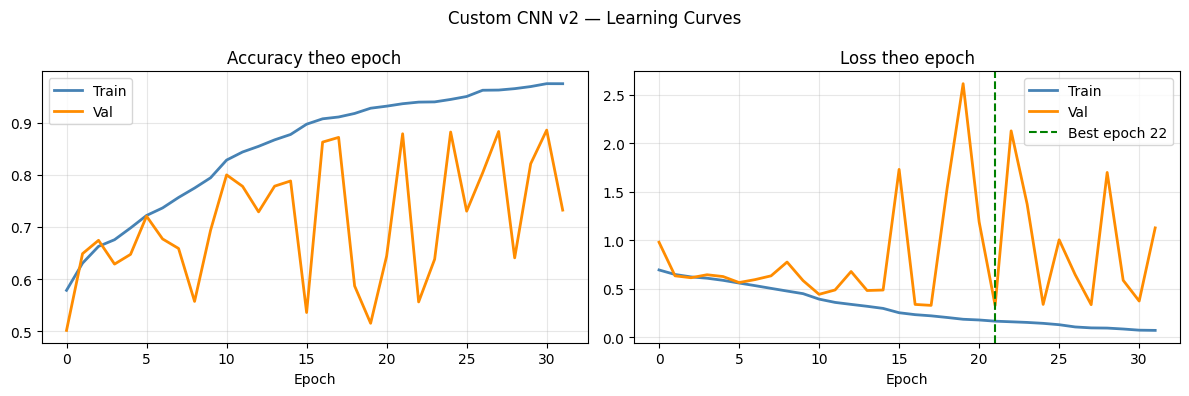

✅ Saved: /kaggle/working/reports/cnn_v2_learning_curves.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'],     label='Train', color='steelblue',  linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val',   color='darkorange', linewidth=2)
axes[0].set_title('Accuracy theo epoch')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'],     label='Train', color='steelblue',  linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val',   color='darkorange', linewidth=2)
best_ep = int(np.argmin(history.history['val_loss']))
axes[1].axvline(best_ep, color='green', linestyle='--',
                label=f'Best epoch {best_ep+1}')
axes[1].set_title('Loss theo epoch')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Custom CNN v2 — Learning Curves')
plt.tight_layout()
save_path = os.path.join(REPORTS_DIR, 'cnn_v2_learning_curves.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved: {save_path}")

## 5. Đánh giá trên Test Set

✅ Loaded: /kaggle/working/models/cnn_v2_best.keras

  KẾT QUẢ: Custom CNN v2
  Accuracy  : 0.8673  (86.73%)
  Precision : 0.8457
  Recall    : 0.8987
  F1-score  : 0.8714
  ROC-AUC   : 0.9403


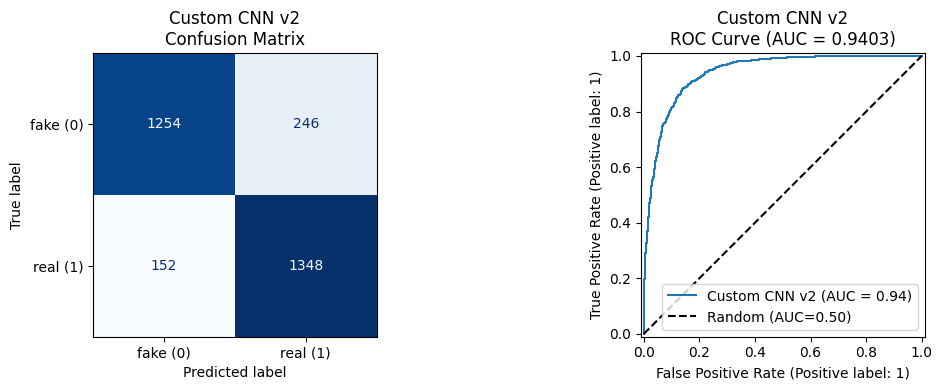

  Đã lưu biểu đồ → /kaggle/working/reports/custom_cnn_v2_evaluation.png


📊 So sánh:
   SVM + HOG     → Acc=72.3%  AUC=0.80
   Custom CNN v1 → Acc=59.8%  AUC=0.67  (underfitting)
   MobileNetV2   → Acc=81.3%
   Custom CNN v2 → Acc=86.7%  AUC=0.94


In [6]:
best_model = keras.models.load_model(MODEL_PATH)
print(f"✅ Loaded: {MODEL_PATH}")

y_true, y_prob = [], []
for images, labels in test_ds:
    proba = best_model.predict(images, verbose=0)
    y_prob.extend(proba.flatten().tolist())
    y_true.extend(labels.numpy().tolist())

y_true = np.array(y_true)
y_prob = np.array(y_prob)
y_pred = (y_prob >= 0.5).astype(int)

results = evaluate_model(
    y_true     = y_true,
    y_pred     = y_pred,
    y_prob     = y_prob,
    model_name = 'Custom CNN v2',
    save_dir   = REPORTS_DIR,
)

print("\n📊 So sánh:")
print(f"   SVM + HOG     → Acc=72.3%  AUC=0.80")
print(f"   Custom CNN v1 → Acc=59.8%  AUC=0.67  (underfitting)")
print(f"   MobileNetV2   → Acc=81.3%")
print(f"   Custom CNN v2 → Acc={results['accuracy']:.1%}  AUC={results['roc_auc']:.2f}")

## 6. Lưu kết quả

In [7]:
RESULTS_CSV = os.path.join(REPORTS_DIR, 'all_results.csv')
df_new = pd.DataFrame([results])

if os.path.exists(RESULTS_CSV):
    df_old = pd.read_csv(RESULTS_CSV)
    df_old = df_old[df_old['model'] != results['model']]
    df_new = pd.concat([df_old, df_new], ignore_index=True)

df_new.to_csv(RESULTS_CSV, index=False)
print("✅ Lưu all_results.csv xong")
print("\n=== BẢNG SO SÁNH ===")
print(df_new.to_string(index=False))

# Liệt kê output files để biết cần download gì
print("\n📁 Output files:")
for root, dirs, files in os.walk(OUTPUT_DIR):
    for f in files:
        p = os.path.join(root, f)
        mb = os.path.getsize(p)/1024/1024
        print(f"   {p}  ({mb:.1f} MB)")
print("\n→ Save Version để download từ Output tab")

✅ Lưu all_results.csv xong

=== BẢNG SO SÁNH ===
        model  accuracy  precision  recall     f1  roc_auc
Custom CNN v2    0.8673     0.8457  0.8987 0.8714   0.9403

📁 Output files:
   /kaggle/working/__notebook__.ipynb  (6.3 MB)
   /kaggle/working/reports/all_results.csv  (0.0 MB)
   /kaggle/working/reports/cnn_v2_learning_curves.png  (0.1 MB)
   /kaggle/working/reports/custom_cnn_v2_evaluation.png  (0.1 MB)
   /kaggle/working/models/cnn_v2_best.keras  (79.4 MB)

→ Save Version để download từ Output tab
